In [490]:
import numpy as np
import PACKAGE_LAB

import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors
from importlib import reload
PACKAGE_LAB = reload(PACKAGE_LAB)

from PACKAGE_LAB import LL_RT,PID_RT,IMC_Tuning
from package_DBR import SelectPath_RT, Delay_RT, Process




## Lead lag real time

In [491]:
help(LL_RT)

Help on function LL_RT in module PACKAGE_LAB:

LL_RT(MV, Kp, TLead, TLag, Ts, PV, PVInit=0, method='EBD')



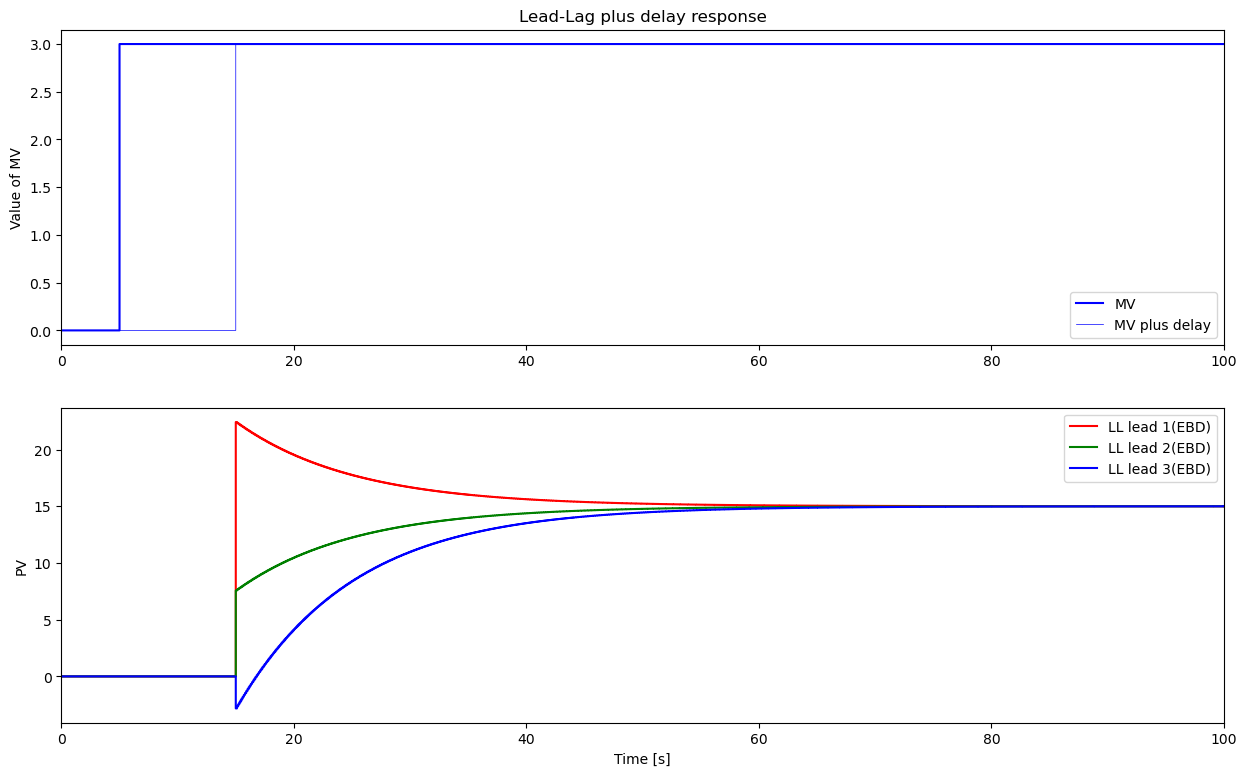

In [492]:
TSim = 100
Ts = 0.1
N = int(TSim / Ts) + 1
theta = 5
Kp = 5

Tlead_1 = 15
Tlead_2 = 5
Tlead_3 = -2
Tlag = 10
theta = 10

global MVFF
MVPath = {0: 0, 5:3, TSim: 3}
t = []
MV = []
PV = []
MVDelay = []
PV_EBD_1 = []
PV_EBD_LEAD1 = []
PV_EBD_LEAD2 = []
PV_EBD_LEAD3 = []

for i in range(0, N):
    t.append(i * Ts)
    SelectPath_RT(MVPath, t, MV)
    Delay_RT(MV, theta, Ts, MVDelay)
    LL_RT(MVDelay, Kp, Tlead_1, Tlag, Ts, PV_EBD_LEAD1)
    LL_RT(MVDelay, Kp, Tlead_2, Tlag, Ts, PV_EBD_LEAD2)
    LL_RT(MVDelay, Kp, Tlead_3, Tlag, Ts, PV_EBD_LEAD3)

plt.figure(figsize=(15, 9))

plt.subplot(2, 1, 1)
plt.step(t, MV, 'b-', label='MV', where='post')
plt.step(t, MVDelay, 'b-', linewidth=0.5, label='MV plus delay', where='post')
plt.ylabel('Value of MV')
plt.title('Lead-Lag plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2, 1, 2)
plt.step(t, PV_EBD_LEAD1, 'r-', label='LL lead 1(EBD)', where='post')
plt.step(t, PV_EBD_LEAD2, 'g-', label='LL lead 2(EBD)', where='post')
plt.step(t, PV_EBD_LEAD3, 'b-', label='LL lead 3(EBD)', where='post')

plt.ylabel('PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.show()

# IMC tuning

In [493]:
help(IMC_Tuning)

Help on function IMC_Tuning in module PACKAGE_LAB:

IMC_Tuning(Kp, theta, T, T2=0, gamma=0.1, order=1)



Help on function IMC_tuning in module PACKAGE_LAB:

IMC_Tuning(Kp,theta,T,T2=0,gamma=0.1,order=1)

In [494]:
Kp = 5
Kc,Ti,Td = IMC_Tuning(Kp,theta,Tlead_1)

# PID implementation 

In [495]:
help(PID_RT)

Help on function PID_RT in module PACKAGE_LAB:

PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVmin, MVmax, MV, MVP, MVI, MVD, E, ManFF=False, PVinit=0, method='EBD-EBD')



Help on function PID_RT in module PACKAGE_LAB:

PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVmin, MVmax, MV, MVP, MVI, MVD, E, ManFF=False, PVinit=0, method ='EBD-EBD'):

In [496]:
Tsim = 500
Ts = 1
N = int(TSim / Ts) + 1

SPpath ={0: 30, 20: 50, 40: 150, 60: 30,70:50,100:20, Tsim: 100}
#SPpath ={0:0,20:50, Tsim: 250}
#PVpath = {0:10,30:50,60:70,70:40,80:20,Tsim:250}
PVpath = {0:50,Tsim:250}
ManPath = {0: False,150:True, TSim: False} 
MVManPath = {0: 0,50:40,70:0, TSim: 0}
MVFFPath = {0: 0, TSim: 0}


alpha = 0.9


SP = []
Man = [] # automatique False, manuel True
MVMan = []
MVFF = []
E = []
MVP = []
MVI = []
MVD = []
MV = []
PV = []
t = []
MVDelay = []

MVmin = 0
MVmax = 100



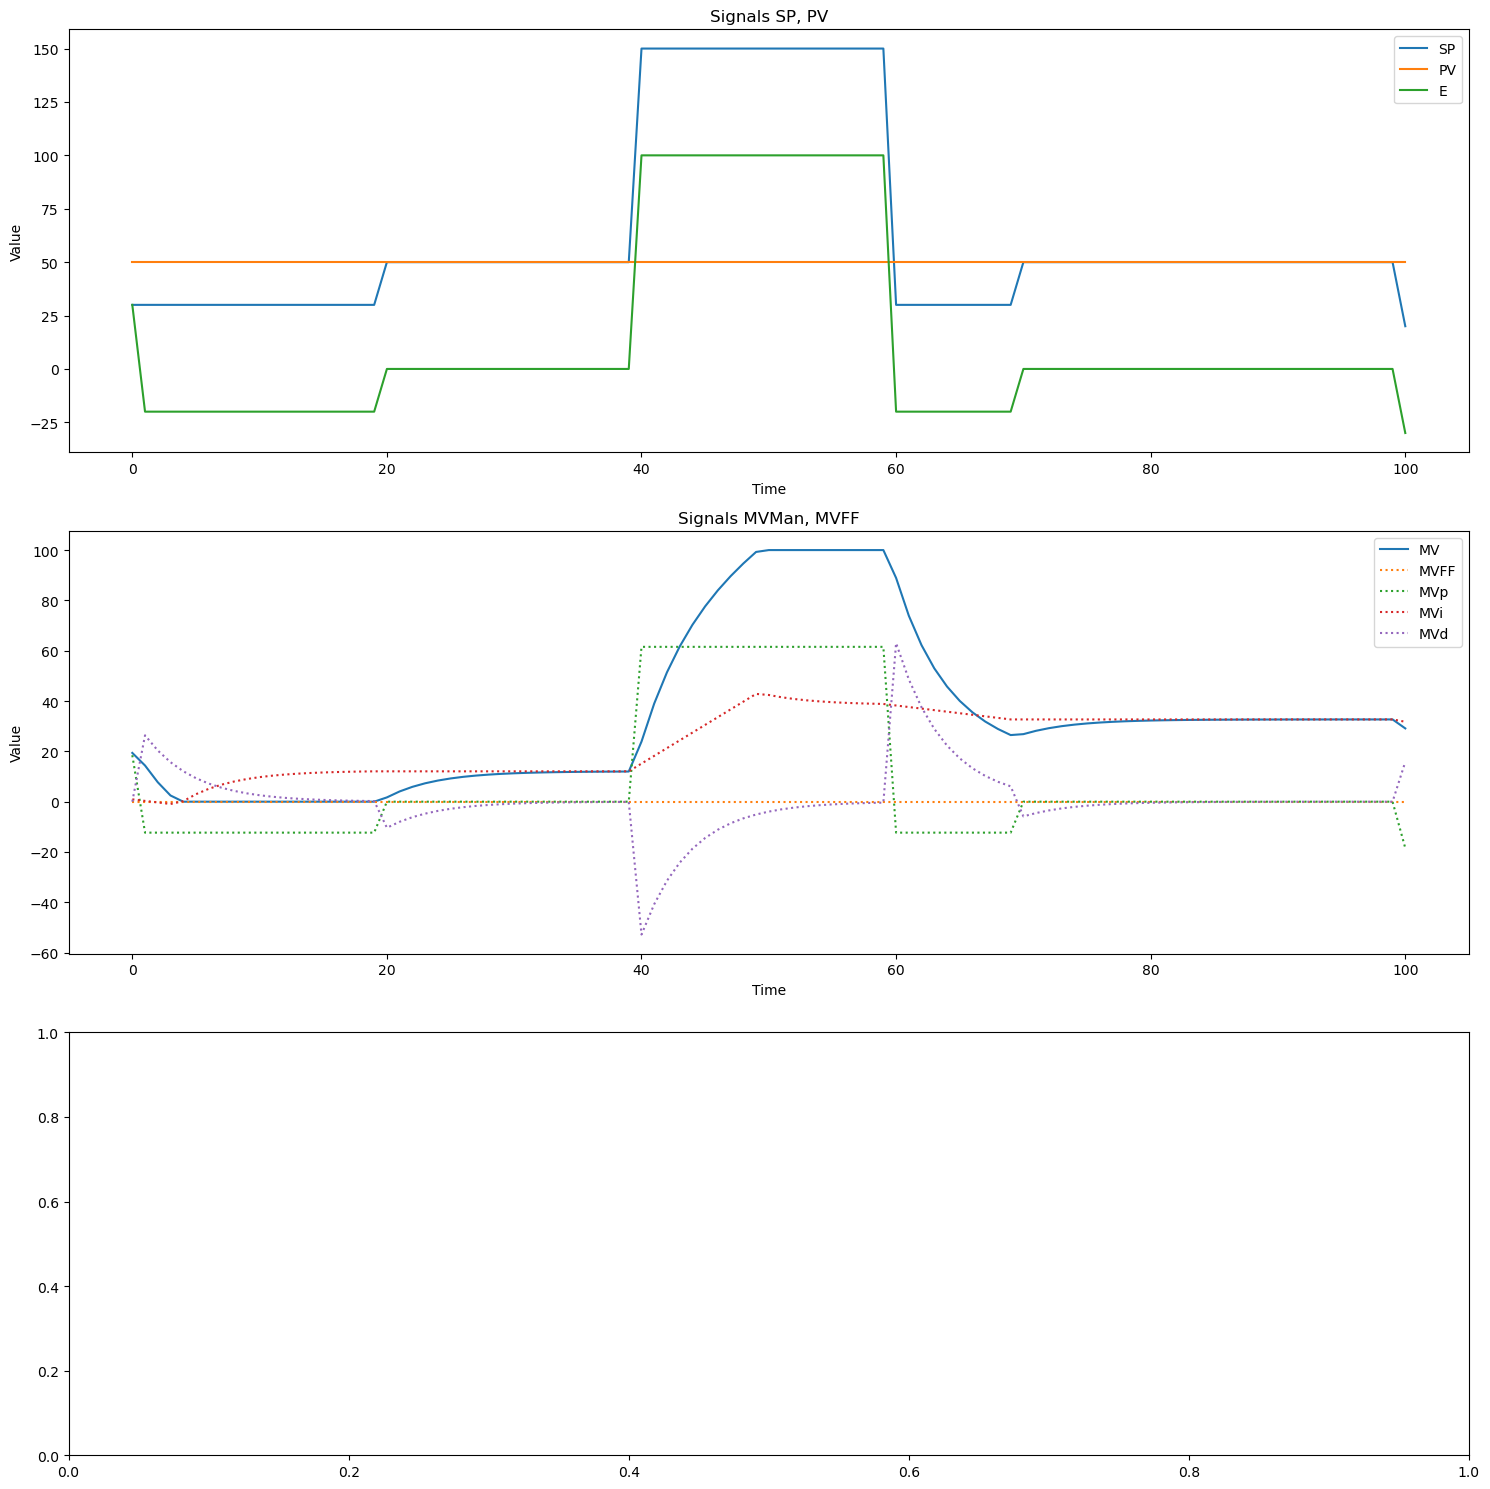

In [ ]:
for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(SPpath,t,SP)
    SelectPath_RT(PVpath,t,PV)
    SelectPath_RT(ManPath, t, Man)
    SelectPath_RT(MVManPath,t,MVMan)
    SelectPath_RT(MVFFPath,t,MVFF)
    
for i in range(0,N):
    PID_RT(SP[0:i+1], PV[0:i+1], Man[0:i+1], MVMan[0:i+1], MVFF[0:i+1], Kc, Ti, Td, alpha, Ts, MVmin, MVmax, MV, MVP, MVI, MVD, E, ManFF=False, PVinit=0, method ='EBD-EBD')


fig, axs = plt.subplots(3, 1, figsize=(15, 15))

axs[0].plot(t, SP, label='SP')
axs[0].plot(t, PV, label='PV')
axs[0].plot(t, E, label='E')
axs[0].set_title('Signals SP, PV')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Value')
axs[0].legend()


axs[1].plot(t, MV, label='MV')  
axs[1].plot(t, MVFF, linestyle=':', label='MVFF')  
axs[1].plot(t, MVP, linestyle=':', label='MVp')
axs[1].plot(t, MVI, linestyle=':', label='MVi')
axs[1].plot(t, MVD, linestyle=':', label='MVd')
axs[1].set_title('Signals MVMan, MVFF')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Value')
axs[1].legend()

axs[2].plot(t, MVMan, linestyle=':', label='MVMan')  
axs[2].plot(t, Man, label='Man')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Value')
axs[2].legend()

plt.tight_layout()
plt.show()